In [1]:
# Initial Setup for Notebook
import pathlib
import data_conduit
from data_conduit.qc import (
    qc_datastructure,
    plot_path_grid,
    DEFAULT_CENTROID_POINTS,
    training_spec,
    training_session_names,
    filter_trials,
    summarise_training_filter,
    TRAINING_DETAIL,
    TRAINING_FIRST_MID_LAST_DETAIL,
    TRAINING_PHASE_LABELS,
)

from movement.plots import plot_centroid_trajectory
import movement.kinematics as kin
from data_conduit.qc.slicing import slice_pose_for_trial
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr

# Training data root. The sessions listed in Training-trials_detail.xlsx live under
# BonsaiOutput/Training (NOT the Test tree). Their spreadsheet "day" numbers do not
# match the on-disk Day<N> folders, so sessions are selected by Bonsai filename via
# `include=` in the next cell, not by day.
ROOT = pathlib.Path('/media/sepi/Elements1/PathIntegrationProtocol/BonsaiOutput/Training')

In [2]:
# Session selection (step 1 of 2)
# Load ONLY the training sessions listed in Celia's spreadsheet. The learning-strategy
# figures below (success rate vs TTP, success rate vs outbound path length, and the
# outbound / inbound trajectory grids) use each mouse's FIRST, MIDDLE and LAST training
# day, transcribed in data_conduit.qc.TRAINING_FIRST_MID_LAST_DETAIL. (Swap in the
# default TRAINING_DETAIL, i.e. training_spec(), for the 5-day D1-D5 progression.)
# This yields the FULL, UNFILTERED trial table so it can be inspected here; trial-level
# filtering is done separately in the next cell.
spec = training_spec(TRAINING_FIRST_MID_LAST_DETAIL)   # first / mid / last day per mouse (min_trial, exclude_on, ...)
spec['phase'] = spec['training_day'].map(TRAINING_PHASE_LABELS)   # 1->'first', 2->'mid', 3->'last' for readable plot labels

datastructure = qc_datastructure(
    root = ROOT,
    depth = 2,                                                                        # session folders sit 2 levels below root: <mouseID>/<day>/<session>
    level_names = ('mouseID', 'day'),                                                 # provenance columns kept on every entry
    streams = ('events', 'nosepoke', 'soundcard', 'session_settings', 'video', 'dlc'),
    include = training_session_names(spec),                                           # restrict to the spreadsheet's Bonsai sessions (matched by session name, NOT day)
    # exclude = None,
    # device_yaml = './device.yml',
    # soundcard_yaml = './soundcard.yml',
    # nosepoke_count = 18,
    # trial_start_buffer = 0.0,
    # l0_selector = None,                                                             # l0 -> mouseID, l1 -> day (l2/session filtering is done by include= above)
)

result = datastructure.load()                # apply the catalog to each session and concatenate across sessions
trials = result['trials']                    # unfiltered: every trial of every selected session (inspect before filtering)
trials


                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  


2026-07-03 18:55:02.332 | WARNING  | data_conduit.datastructure:read_session:236 - /home/sepi/dataconduit_workspace/data-conduit/src/data_conduit/datastructure.py:551: UserWarning: reader 'dlc' skipped for session '2026-05-28T154840Z': FileNotFoundError: no 'DLC' folder in session /media/sepi/Elements1/PathIntegrationProtocol/BonsaiOutput/Training/MbL_M01569517/Day17/2026-05-28T154840Z.
  objects = self.catalog.read_session(info['path'])

2026-07-03 18:55:02.530 | WARNING  | data_conduit.datastructure:read_session:236 - /home/sepi/dataconduit_workspace/data-conduit/src/data_conduit/datastructure.py:551: UserWarning: reader 'dlc' skipped for session '2026-05-29T155941Z': FileNotFoundError: no 'DLC' folder in session /media/sepi/Elements1/PathIntegrationProtocol/BonsaiOutput/Training/MbL_M01569517/Day18/2026-05-29T155941Z.
  objects = self.catalog.read_session(info['path'])



,trial_index,start_time,end_time,tz_triggered_time,outbound_start_time,outbound_end_time,inbound_start_time,inbound_end_time,TTT,TTP,ChosenPort,CorrectPort,outcome,LED,angle_offset,target_zone_size,session,mouseID,day
0,1,22852.592992,22879.349984,22874.800992,22852.592992,22874.800992,22874.800992,22879.349984,22.208000,4.548992,14,14,Success,ON,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2
1,2,22879.349984,22923.335488,22921.252000,22879.349984,22921.252000,22921.252000,22923.335488,41.902016,2.083488,14,14,Success,ON,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2
2,3,22923.335488,22935.201984,22932.852992,22923.335488,22932.852992,22932.852992,22935.201984,9.517504,2.348992,14,14,Success,ON,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2
3,4,22935.201984,22945.540000,22944.252000,22935.201984,22944.252000,22944.252000,22945.540000,9.050016,1.288000,14,14,Success,ON,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2
4,5,22945.540000,22955.582464,22954.052000,22945.540000,22954.052000,22954.052000,22955.582464,8.512000,1.530464,14,14,Success,ON,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2479,60,16173.513984,16196.815488,16191.792000,16173.513984,16191.792000,16191.792000,16196.815488,18.278016,5.023488,-1,16,Miss,OFF,NaN,150.0,2026-05-14T135225Z,MbR_M01569518,Day9
2480,61,16196.815488,16374.456992,16369.442976,16196.815488,16369.442976,16369.442976,16374.456992,172.627488,5.014016,-1,16,Miss,OFF,NaN,150.0,2026-05-14T135225Z,MbR_M01569518,Day9
2481,62,16374.456992,16461.362976,16456.342976,16374.456992,16456.342976,16456.342976,16461.362976,81.885984,5.020000,-1,16,Miss,OFF,NaN,150.0,2026-05-14T135225Z,MbR_M01569518,Day9
2482,63,16461.362976,16474.692000,16472.442976,16461.362976,16472.442976,16472.442976,16474.692000,11.080000,2.249024,16,16,Success,OFF,NaN,150.0,2026-05-14T135225Z,MbR_M01569518,Day9


In [3]:
print("Loaded streams:\n============================================")
for stream in datastructure:
    print(f'    ID| {stream}\n    ======================')
    display(datastructure[stream].to_dataframe().head() if hasattr(datastructure[stream], 'to_dataframe') else datastructure[stream].head())
    print(f'Total entries: {len(datastructure[stream])}\n\n')


Loaded streams:
    ID| nosepoke:Activations


,,device,register,localID,session,mouseID,day,Activations_data
Time,peripherals,,,,,,,


Total entries: 0


    ID| nosepoke:LEDs


,,device,register,localID,session,mouseID,day,LEDs_data
Time,peripherals,,,,,,,


Total entries: 0


    ID| nosepoke:Valves


...

Total entries: 991102


    ID| dlc:confidence


session        mouseID   day  confidence
Time         keypoints                                                     
22849.683584 nose       2026-04-23T160907Z  FLR_M01569521  Day2    0.978499
             lear       2026-04-23T160907Z  FLR_M01569521  Day2    0.931897
             rear       2026-04-23T160907Z  FLR_M01569521  Day2    0.829694
             body       2026-04-23T160907Z  FLR_M01569521  Day2    0.846847
             tailbase   2026-04-23T160907Z  FLR_M01569521  Day2    0.830134

Total entries: 991102


    ID| trials


,trial_index,start_time,end_time,tz_triggered_time,outbound_start_time,outbound_end_time,inbound_start_time,inbound_end_time,TTT,TTP,ChosenPort,CorrectPort,outcome,LED,angle_offset,target_zone_size,session,mouseID,day
0,1,22852.592992,22879.349984,22874.800992,22852.592992,22874.800992,22874.800992,22879.349984,22.208000,4.548992,14,14,Success,ON,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2
1,2,22879.349984,22923.335488,22921.252000,22879.349984,22921.252000,22921.252000,22923.335488,41.902016,2.083488,14,14,Success,ON,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2
2,3,22923.335488,22935.201984,22932.852992,22923.335488,22932.852992,22932.852992,22935.201984,9.517504,2.348992,14,14,Success,ON,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2
3,4,22935.201984,22945.540000,22944.252000,22935.201984,22944.252000,22944.252000,22945.540000,9.050016,1.288000,14,14,Success,ON,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2
4,5,22945.540000,22955.582464,22954.052000,22945.540000,22954.052000,22954.052000,22955.582464,8.512000,1.530464,14,14,Success,ON,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2


Total entries: 2484




In [4]:
datastructure['nosepoke:Activations']

<xarray.DataArray 'Activations_data' (Time: 0, peripherals: 18)> Size: 0B

Coordinates:
  * Time         (Time) float64 0B 
    session      (Time) <U18 0B 
    mouseID      (Time) object 0B 
    day          (Time) object 0B 
  * peripherals  (peripherals) <U5 360B 'NP_0' 'NP_1' 'NP_2' ... 'NP_16' 'NP_17'
    device       (peripherals) <U9 648B 'Behavior0' 'Behavior0' ... 'Behavior5'
    register     (peripherals) <U2 144B '32' '32' '32' '32' ... '32' '32' '32'
    localID      (peripherals) <U7 504B 'DIPort0' 'DIPort1' ... 'DIPort2'
Attributes:
    description:        Base DataArray for unified coordinates of type Activa...
    source:             Constructed using construct_base_da function
    _lookup_array_ref:  <xarray.DataArray 'Activations_lookup' (peripherals: ...

# Filtering

Trials are filtered per `Training-trials_detail.xlsx` (Celia), transcribed into
`data_conduit.qc.TRAINING_DETAIL`. This is split into **two independent steps** so the
unfiltered trial table can be inspected first:

1. **Session selection** (cell above): `training_session_names(spec)` restricts the load to
   exactly the Bonsai sessions the spreadsheet lists. Sessions are matched by their **Bonsai
   filename, not by day** — the spreadsheet's day numbers do *not* line up with the on-disk
   `Day<N>` folders (e.g. FL "day 2" = `2026-05-11T125643Z` actually lives under `Day7`).

2. **Trial filtering** (cell below): `filter_trials(trials, spec)` applies the per-session rules:
   - every session: keep `trial_index >= min_trial` (the spreadsheet's *"X to end"*);
   - `MR_M01569515` / `MbR_M01569518` only: additionally drop the mid-session cue trials — the
     block protocol runs `1 ON, then 20/25 OFF`, so the cue trials are exactly the `LED == 'ON'`
     trials in the kept range. **All** in-range ON trials are dropped, which follows the recorded
     LED state even where a session ran short or over-ran the spreadsheet's annotated block count.

   Combined days (the *"COMBINE ... SESSIONS"* rows) share one `training_day` and are renumbered
   `1..N` across their pooled sessions as `day_trial_index`. Edit `TRAINING_DETAIL` in
   `training_filter.py` if the spreadsheet changes.

In [5]:
# Trial filtering (step 2 of 2)
# Apply the per-session spreadsheet rules to the loaded `trials`. Kept separate from
# session selection so the unfiltered `trials` can be inspected above. `filter_trials`
# prints a per-session keep/drop summary (report=True by default); pass report=False to
# silence it, or call summarise_training_filter(trials, spec) to preview without filtering.
trials_filtered = filter_trials(trials, spec)
trials_filtered

      mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
FLR_M01569521             1 2026-04-23T160907Z       74         11           64       False             0      64
FLR_M01569521             2 2026-04-25T190120Z       22         11           12       False             0      12
FLR_M01569521             2 2026-04-25T190915Z       73         11           63       False             0      63
FLR_M01569521             3 2026-04-28T124013Z       14          6            9       False             0       9
FLR_M01569521             3 2026-04-28T124547Z       68         11           58       False             0      58
FLR_M01569521             4 2026-04-29T161826Z      131         11          121       False             0     121
FLR_M01569521             5 2026-04-30T151438Z      109          6          104       False             0     104
 FL_M01569519             2 2026-05-11T125643Z       98         16           83       Fa

,trial_index,start_time,end_time,tz_triggered_time,outbound_start_time,outbound_end_time,inbound_start_time,inbound_end_time,TTT,TTP,...,CorrectPort,outcome,LED,angle_offset,target_zone_size,session,mouseID,day,training_day,day_trial_index
0,11,23009.675488,23021.869984,23016.854976,23009.675488,23016.854976,23016.854976,23021.869984,7.179488,5.015008,...,14,Miss,OFF,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2,1,1
1,12,23021.869984,23030.656000,23027.952992,23021.869984,23027.952992,23027.952992,23030.656000,6.083008,2.703008,...,14,Success,OFF,NaN,150.0,2026-04-23T160907Z,FLR_M01569521,Day2,1,2
2,13,23030.656000,23040.496480,23037.102976,23030.656000,23037.102976,23037.102976,23040.496480,6.446976,3.393504,...,14,Success,OFF,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2,1,3
3,14,23040.496480,23051.965984,23046.953984,23040.496480,23046.953984,23046.953984,23051.965984,6.457504,5.012000,...,14,Miss,OFF,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2,1,4
4,15,23051.965984,23066.218976,23061.202976,23051.965984,23061.202976,23061.202976,23066.218976,9.236992,5.016000,...,14,Miss,OFF,NaN,150.0,2026-04-23T160907Z,FLR_M01569521,Day2,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1855,88,8522.236992,8533.254496,8529.316992,8522.236992,8529.316992,8529.316992,8533.254496,7.080000,3.937504,...,13,Success,OFF,NaN,150.0,2026-05-20T102711Z,MbR_M01569518,Day13,5,62
1856,89,8533.254496,8552.430496,8547.418976,8533.254496,8547.418976,8547.418976,8552.430496,14.164480,5.011520,...,13,Miss,OFF,0.0,150.0,2026-05-20T102711Z,MbR_M01569518,Day13,5,63
1857,90,8552.430496,8565.830496,8560.817984,8552.430496,8560.817984,8560.817984,8565.830496,8.387488,5.012512,...,13,Miss,OFF,NaN,150.0,2026-05-20T102711Z,MbR_M01569518,Day13,5,64
1858,91,8565.830496,8592.507488,8587.717984,8565.830496,8587.717984,8587.717984,8592.507488,21.887488,4.789504,...,13,Success,OFF,NaN,150.0,2026-05-20T102711Z,MbR_M01569518,Day13,5,65


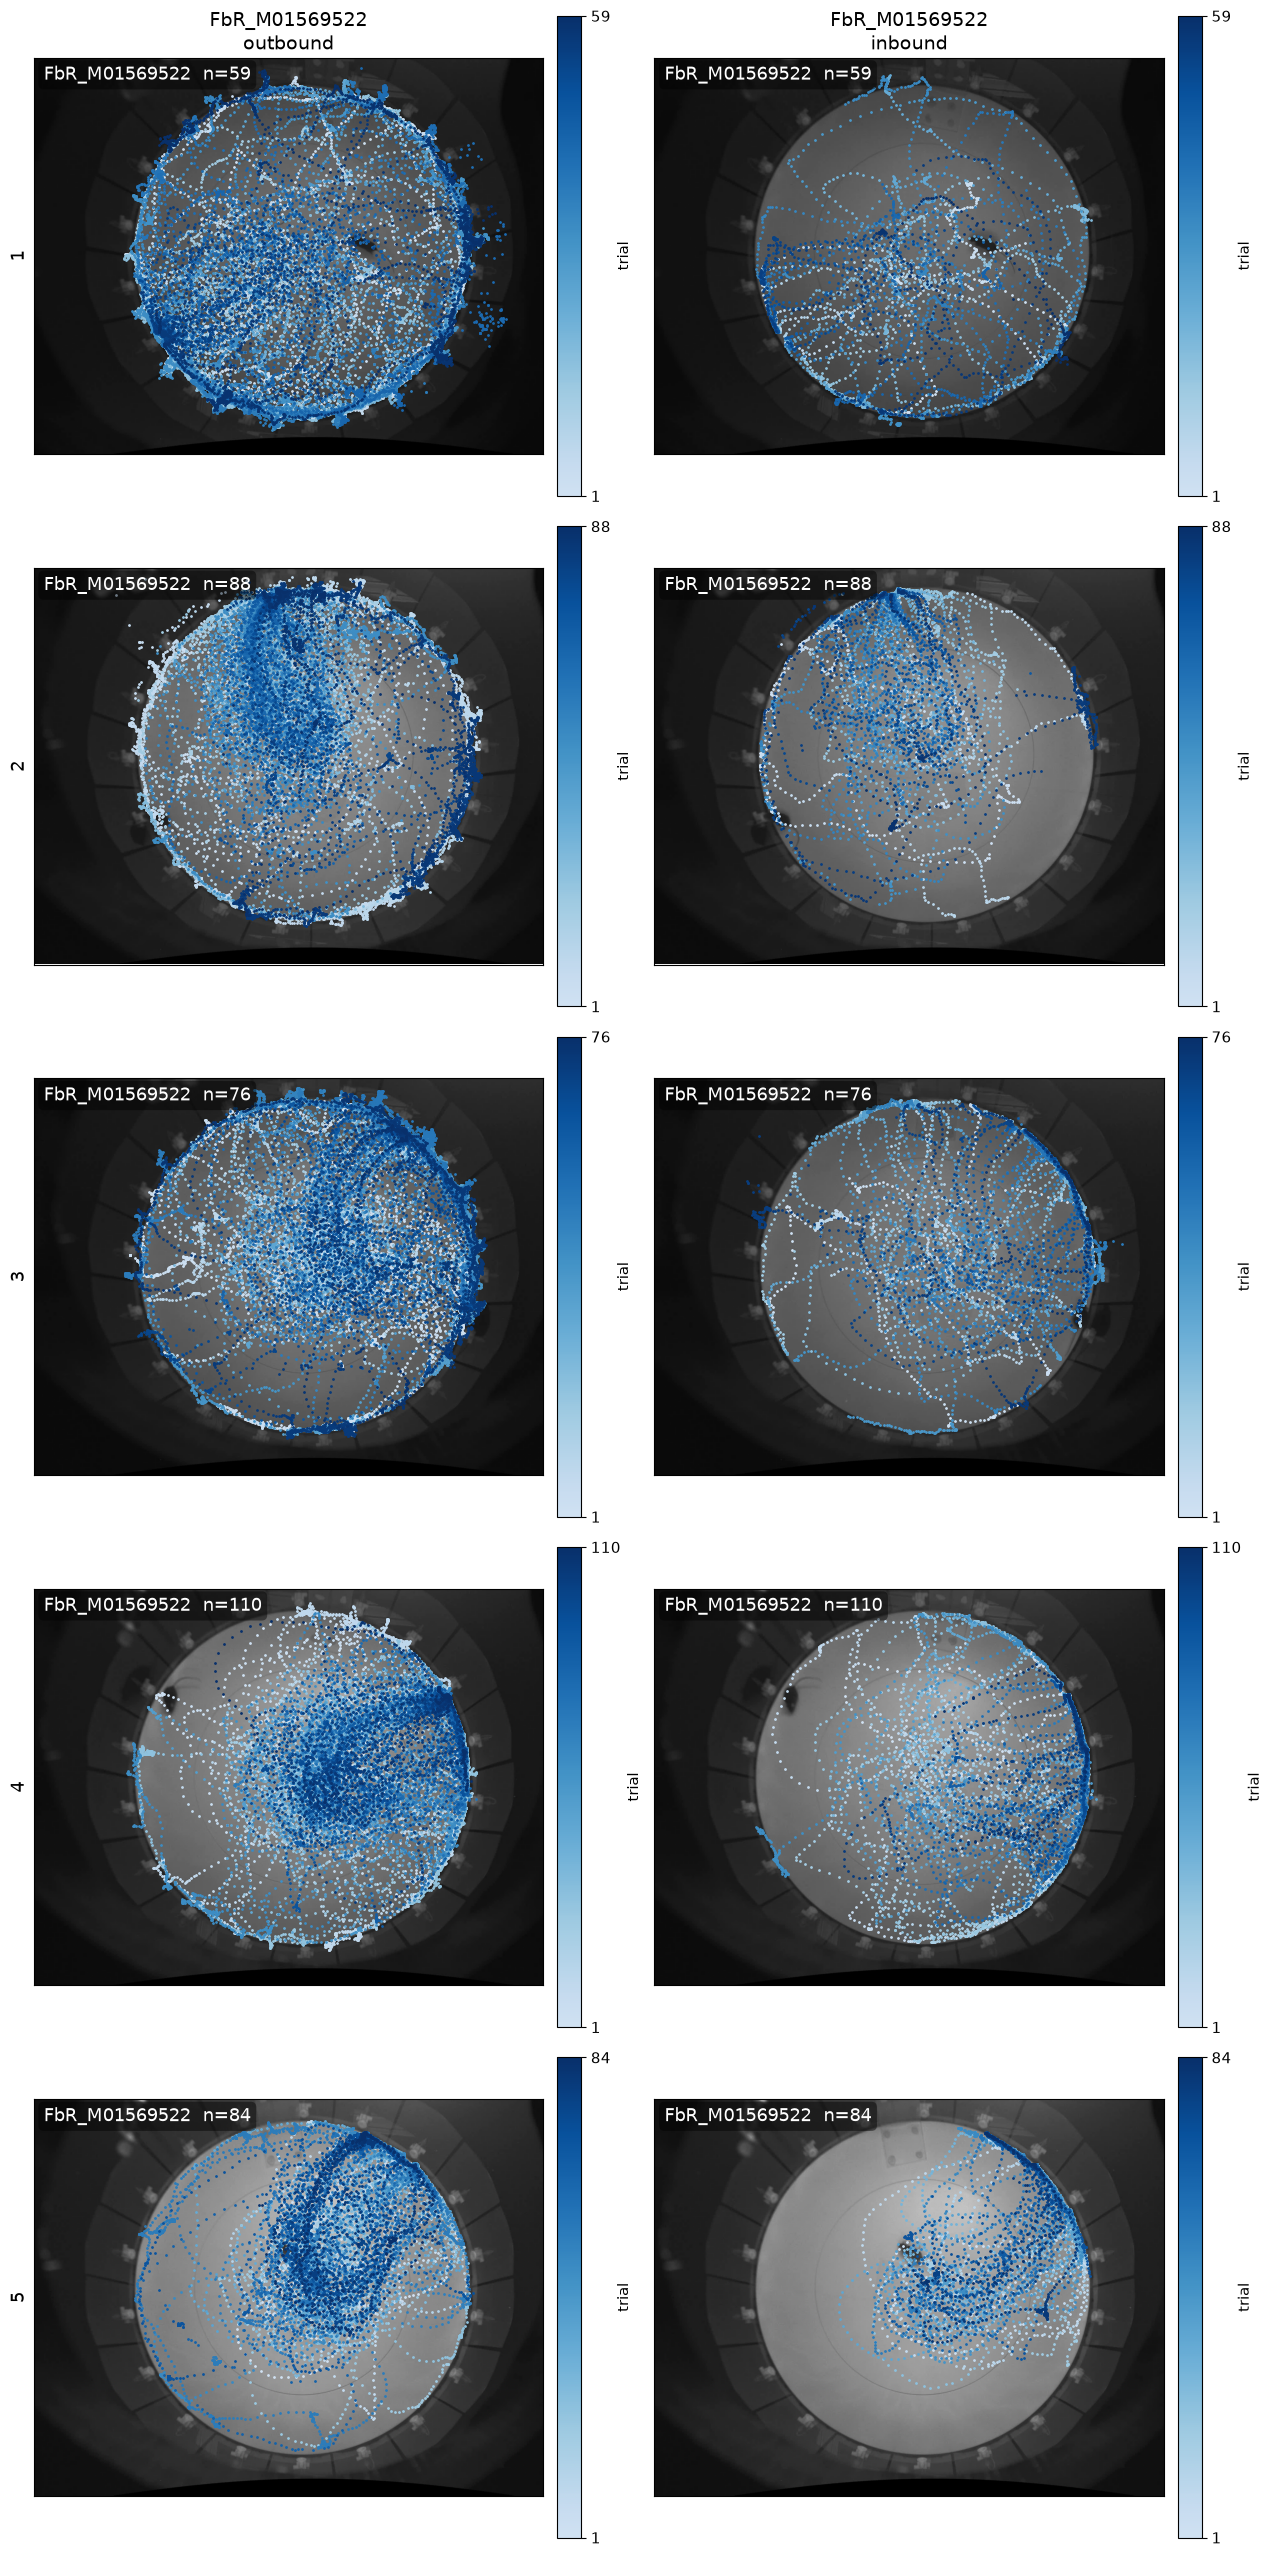

In [ ]:
# Figure 1 | Outbound & inbound trajectories
# Grid: rows = training day, columns = each mouse split into outbound|inbound
# subplots. Trajectories are the DLC centroid path per trial, overlaid on the arena
# frame and coloured light->dark by trial order. Needs DLC pose (sorted into each
# session's DLC/ folder) + the `movement` package; a session with no pose renders as
# the bare frame.
#
# IMPORTANT: DLC was run on the UNDISTORTED video (1620x1260), so the pose lives in
# undistorted pixel coordinates. The background must therefore be the
# `UndistortedVideoData` frame, NOT the raw `VideoData` frame (1440x1080) - drawing
# the raw frame leaves the scatter off-centre / mis-scaled relative to the arena.
#
# The colourbar is labelled with `day_trial_index` (the contiguous 1..N per-day
# counter from filter_trials) so its range matches each panel's trial count `n`;
# the raw `trial_index` restarts and gaps across a combined day, so it would not.
def figure1(result, trials, root, *, mice=None, groups=None,
            row_by='training_day', col_by=('mouseID', 'segment'),
            segments=('outbound', 'inbound'), video_subdir='UndistortedVideoData',
            trial_number_column='day_trial_index', **kwargs):
    """Draw the trajectory grid (via plot_path_grid) for the FILTERED trials.

    mice         : subset of mouseIDs to plot (None = all present).
    groups       : {name: [mice]} to colour by group instead of per-mouse.
    video_subdir : session subfolder for the background frame. Default
                   'UndistortedVideoData' to match the DLC coordinate space.
    trial_number_column : column labelling the colourbar ticks. Default
                   'day_trial_index' (contiguous per day, so it matches `n`).
    kwargs       : forwarded to plot_path_grid (centroid_points, marker_size,
                   cmap_range, figsize_per_cell, ...).
    """
    return plot_path_grid(
        {**result, 'trials': trials}, root,
        mice=mice, groups=groups,
        row_by=row_by, col_by=list(col_by), segments=segments,
        video_subdir=video_subdir,
        trial_number_column=trial_number_column,
        require_pose_for_trials=False,   # sessions/trials without pose -> blank, don't raise
        **kwargs,
    )


# One mouse at a time keeps the grid readable; pass mice=None (or a list) for more.
fig, axes = figure1(result, trials_filtered, ROOT, mice=['FbR_M01569522'])

In [10]:
result.keys()

dict_keys(['nosepoke:Activations', 'nosepoke:LEDs', 'nosepoke:Valves', 'nosepoke:Rewards', 'session_settings:metadata', 'session_settings:trials', 'video', 'dlc:position', 'dlc:confidence', 'trials'])

In [ ]:
display(result['dlc:position'].to_dataframe())

session        mouseID   day  \
Time         keypoints space                                            
22849.683584 nose      x      2026-04-23T160907Z  FLR_M01569521  Day2   
                       y      2026-04-23T160907Z  FLR_M01569521  Day2   
             lear      x      2026-04-23T160907Z  FLR_M01569521  Day2   
                       y      2026-04-23T160907Z  FLR_M01569521  Day2   
             rear      x      2026-04-23T160907Z  FLR_M01569521  Day2   
...                                          ...            ...   ...   
16551.379232 rear      y      2026-05-14T135225Z  MbR_M01569518  Day9   
             body      x      2026-05-14T135225Z  MbR_M01569518  Day9   
                       y      2026-05-14T135225Z  MbR_M01569518  Day9   
             tailbase  x      2026-05-14T135225Z  MbR_M01569518  Day9   
                       y      2026-05-14T135225Z  MbR_M01569518  Day9   

                                position  
Time         keypoints space              
22849.683584 nose      x      881.390381  
                       y       94.272026  
             lear      x      869.043701  
                       y       64.673759  
             rear      x      856.150879  
...                                  ...  
16551.379232 rear      y      745.331177  
             body      x      964.530334  
                       y      707.386963  
             tailbase  x      995.762939  
                       y      688.104126  

[9911020 rows x 4 columns]

In [14]:
pose_wide = (
    result["dlc:position"]
    .to_dataframe(name="value")
    .reset_index()
    .pivot_table(
        index=["session", "Time"],
        columns=["keypoints", "space"],
        values="value",
    )
)

pose_wide.columns = [f"{keypoint}_{space}" for keypoint, space in pose_wide.columns]
pose_wide = pose_wide.reset_index()
pose_wide

,session,Time,body_x,body_y,lear_x,lear_y,nose_x,nose_y,rear_x,rear_y,tailbase_x,tailbase_y
0,2026-04-21T155201Z,22173.497600,1051.098755,590.637939,1016.551636,588.647766,999.560547,575.612305,1021.429504,569.007324,1089.541504,609.793945
1,2026-04-21T155201Z,22173.547552,1030.803345,584.640564,996.213806,582.697083,978.985413,571.398438,999.820435,562.691406,1068.796387,600.568176
2,2026-04-21T155201Z,22173.597568,1009.545044,577.081055,973.620300,576.010864,956.384583,560.770325,978.815735,555.011536,1048.571533,592.467285
3,2026-04-21T155201Z,22173.647552,989.473694,569.046021,954.198669,568.803894,937.183716,558.447632,958.012634,548.456116,1028.655518,581.621033
4,2026-04-21T155201Z,22173.697568,971.157471,563.445190,935.488403,565.439941,918.859680,555.663208,939.090454,543.146423,1012.180237,574.627319
...,...,...,...,...,...,...,...,...,...,...,...,...
991097,2026-05-22T150830Z,17079.885184,1298.287231,992.562134,1300.360352,991.851562,1536.096191,672.519531,1295.661499,991.710205,1297.871460,984.515747
991098,2026-05-22T150830Z,17079.935168,1297.842041,992.878235,1297.391235,992.571716,1536.216064,673.077454,1295.570435,991.847900,1297.724976,984.342346
991099,2026-05-22T150830Z,17079.985184,1297.847534,993.670044,1297.250122,993.370483,1535.536743,672.272278,1295.577637,992.711792,1297.825928,984.621643
991100,2026-05-22T150830Z,17080.035168,1298.012085,992.955078,1297.440918,992.672546,1535.734497,672.481995,1295.711426,992.061462,1297.804077,984.472717


In [21]:
# Columns that define each trial's window. Carry along any label you want as the
# sub-index (trial_index, and day_trial_index if you prefer the contiguous counter).
trial_windows = (
    trials_filtered[["session", "trial_index", "day_trial_index",
                     "start_time", "end_time"]]
    .sort_values("start_time")          # merge_asof needs the merge key globally sorted
    .reset_index(drop=True)
)

pw = pose_wide.sort_values("Time").reset_index(drop=True)   # ditto for the pose side

# For each frame, attach the last trial that STARTED at or before it (same session).
tagged = pd.merge_asof(
    pw, trial_windows,
    left_on="Time", right_on="start_time",
    by="session",                       # only match within the same session
    direction="backward",
)

# merge_asof only checks the start; a frame is really inside the trial only if it
# also lands before the trial's end. Frames in the inter-trial gap (or before the
# first trial) fail this and get dropped.
in_trial = (tagged["Time"] <= tagged["end_time"]).fillna(False)

pose_by_trial = (
    tagged[in_trial]
    # .drop(columns=["start_time", "end_time"])
    .set_index(["session", "trial_index", "Time"])   # trial as a sub-index level
    .sort_index()
)
pose_by_trial.drop(columns=['body_x', 'body_y', 'lear_x', 'lear_y', 'rear_x', 'rear_y', 'tailbase_x', 'tailbase_y'], inplace=True)
display(pose_by_trial)


nose_x       nose_y  \
session            trial_index Time                                    
2026-04-21T155201Z 26.0        22654.447328  380.554047   906.087769   
                               22654.497344  381.084442   905.728394   
                               22654.547328  380.976562   906.158813   
                               22654.597344  380.828308   905.737061   
                               22654.647328  381.112335   905.772522   
...                                                 ...          ...   
2026-05-22T150830Z 71.0        16984.985088  951.515930  1157.990723   
                               16985.035072  945.263550  1158.080566   
                               16985.085088  935.596558  1162.611816   
                               16985.135072  930.693176  1168.613647   
                               16985.185088  926.500916  1169.342896   

                                             day_trial_index    start_time  \
session            trial_index Time                                          
2026-04-21T155201Z 26.0        22654.447328              1.0  22654.444000   
                               22654.497344              1.0  22654.444000   
                               22654.547328              1.0  22654.444000   
                               22654.597344              1.0  22654.444000   
                               22654.647328              1.0  22654.444000   
...                                                      ...           ...   
2026-05-22T150830Z 71.0        16984.985088             48.0  16965.708992   
                               16985.035072             48.0  16965.708992   
                               16985.085088             48.0  16965.708992   
                               16985.135072             48.0  16965.708992   
                               16985.185088             48.0  16965.708992   

                                                 end_time  
session            trial_index Time                        
2026-04-21T155201Z 26.0        22654.447328  22696.874496  
                               22654.497344  22696.874496  
                               22654.547328  22696.874496  
                               22654.597344  22696.874496  
                               22654.647328  22696.874496  
...                                                   ...  
2026-05-22T150830Z 71.0        16984.985088  16985.197984  
                               16985.035072  16985.197984  
                               16985.085088  16985.197984  
                               16985.135072  16985.197984  
                               16985.185088  16985.197984  

[784197 rows x 5 columns]

In [ ]:
# Figure 1b | Per-trial centroid trajectories (small multiples).
# One panel PER TRIAL (not overlaid). Columns = grouping x {outbound, inbound};
# rows = trial slot within the grouping. Each panel is labelled '#<trial number>'
# and drawn over the arena frame with a shared pixel extent. Centroid = mean of
# centroid_points (movement), matching figure1 / the path-length figure.
import time
from data_conduit.qc.path_plots import _first_frame_for_session


def _safe_first_frame(root, session_id, video_subdir, cache, *, retries=2, backoff=0.5):
    """Fault-tolerant _first_frame_for_session.

    The training videos sit on an external USB drive, and reading them under load
    intermittently fails - usually OSError('Could not load meta information') when
    the ffmpeg metadata read times out, but imageio/ffmpeg can raise other types
    too - even though the file itself is fine. Retry a few times, then fall back to
    None (blank background) with a warning, so one flaky read can't abort the whole
    grid. A background frame is decorative, hence the broad catch. Cached per session.
    """
    if session_id in cache:
        return cache[session_id]
    frame = None
    for attempt in range(retries + 1):
        try:
            frame = _first_frame_for_session(root, session_id, video_subdir, {})   # fresh dict -> force read
            break
        except Exception as exc:   # any read failure -> blank background, never abort the figure
            if attempt < retries:
                time.sleep(backoff)
                continue
            detail = (str(exc).strip().splitlines() or [''])[0][:100]
            print(f"warning: frame read failed for session {session_id!r} after "
                  f"{retries + 1} tries ({exc.__class__.__name__}: {detail}); "
                  f"drawing that panel without a background.")
    cache[session_id] = frame
    return frame


def figure_per_trial(
        result, trials, root, mouse, *,
        group_by='training_day',                 # outer columns: 'session' or 'training_day'
        trial_number_column=None,                # panel label; defaults to match group_by
        segments=('outbound', 'inbound'),        # subcolumns
        centroid_points=DEFAULT_CENTROID_POINTS, # centroid = mean of these keypoints
        segment_colors=('tab:blue', 'tab:orange'),
        video_subdir='UndistortedVideoData',
        mouse_column='mouseID', session_column='session',
        pose_key='dlc:position', time_coord='Time',
        marker_size=6, figsize_per_cell=(2.3, 1.9), max_trials=None):
    """Small-multiples grid of per-trial centroid paths for ONE mouse.

    Row r of a grouping column is that grouping's r-th trial (sorted by trial number);
    groupings with fewer trials leave blank rows. Each panel is labelled with the
    grouping's own trial number, so labels stay correct even when numbers differ
    across columns (e.g. per-session trial_index vs per-day day_trial_index).
    """
    pose = result[pose_key]
    sub = trials[trials[mouse_column] == mouse]
    if sub.empty:
        raise ValueError(f'no trials for mouse {mouse!r}.')

    if trial_number_column is None:
        trial_number_column = ('day_trial_index'
                               if group_by in ('training_day', 'day') and 'day_trial_index' in sub
                               else 'trial_index')

    groupings = sorted(pd.unique(sub[group_by]))
    seg_color = dict(zip(segments, segment_colors))
    per_group = {g: sub[sub[group_by] == g].sort_values(trial_number_column).reset_index(drop=True)
                 for g in groupings}
    nrows = max(len(df) for df in per_group.values())
    if max_trials is not None:
        nrows = min(nrows, max_trials)
    blocks = [(g, seg) for g in groupings for seg in segments]   # column order
    ncols = len(blocks)

    # Pre-load each session's arena frame ONCE, up front and fault-tolerantly, so the
    # heavy render loop below only reads cached arrays. (Reading these external-drive
    # videos while rendering hundreds of big panels is what triggered the intermittent
    # ffmpeg 'Could not load meta information' error.) A reference frame then fixes a
    # shared pixel extent so the whole arena is visible in every panel.
    frame_cache = {}
    for s in pd.unique(sub[session_column]):
        _safe_first_frame(root, s, video_subdir, frame_cache)
    ref = next((f for f in frame_cache.values() if f is not None), None)
    extent = ref.shape[:2] if ref is not None else None   # (H, W)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_cell[0] * ncols, figsize_per_cell[1] * nrows),
        squeeze=False,
    )
    for ci, (g, seg) in enumerate(blocks):
        gdf = per_group[g]
        for r in range(nrows):
            ax = axes[r][ci]
            if r >= len(gdf):
                ax.axis('off')
                continue
            row = gdf.iloc[r]

            frame = _safe_first_frame(root, row[session_column], video_subdir, frame_cache)
            if frame is not None:
                ax.imshow(frame, origin='upper')

            sliced = slice_pose_for_trial(pose, row, segment=seg, time_coord=time_coord)
            if sliced.sizes.get(time_coord, 0) > 0:
                movement_pose = (sliced.rename({time_coord: 'time', 'keypoints': 'keypoint'})
                                 .expand_dims({'individual': ['ind']}))
                plot_centroid_trajectory(movement_pose, keypoints=list(centroid_points),
                                         ax=ax, c=seg_color[seg], s=marker_size)

            # plot_centroid_trajectory writes its own title/labels; override AFTER it.
            if extent is not None:
                ax.set_xlim(0, extent[1]); ax.set_ylim(extent[0], 0)
            else:
                ax.invert_yaxis()
            ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel(''); ax.set_ylabel('')
            tnum = row[trial_number_column]
            ax.set_title(f"{g}\n{seg}" if r == 0 else '', fontsize=9)
            ax.text(0.04, 0.96, f"#{int(tnum)}" if pd.notna(tnum) else "#?",
                    transform=ax.transAxes, va='top', ha='left', fontsize=7, color='white',
                    bbox=dict(boxstyle='round', fc='black', alpha=0.45, ec='none'))

    fig.suptitle(f"{mouse}: per-trial centroid paths  (columns = {group_by} x segment)", y=1.0)
    fig.tight_layout()
    return fig, axes


# One mouse at a time (a session/day belongs to one mouse). group_by='session' for a
# per-session breakdown. NOTE: with group_by='training_day' the tallest day sets the
# row count (FbR day 4 = 110 trials -> a ~209-inch figure); pass max_trials=... to cap
# rows, or shrink figsize_per_cell, until you're ready for the full-height render.
fig, axes = figure_per_trial(result, trials_filtered, ROOT, 'FbR_M01569522',
                             group_by='training_day', max_trials=20)


In [ ]:
# Figure 1c | Overlaid centroid trajectories (ONE row).
# Same per-trial drawing as figure 1b, but every trial of a (grouping, segment) is
# OVERLAID on a single panel instead of getting its own row. Columns = grouping x
# {outbound, inbound}; one row. This is essentially what figure 1a (plot_path_grid)
# does, so it renders in seconds - proof that 1b's minutes come from having hundreds
# of panels (each re-drawing the full arena frame + tight_layout), not the pose data.
# Reuses _safe_first_frame / slice_pose_for_trial / movement from the figure 1b cell.
def figure_overlay(
        result, trials, root, mouse, *,
        group_by='training_day',
        segments=('outbound', 'inbound'),
        centroid_points=DEFAULT_CENTROID_POINTS,
        segment_colors=('tab:blue', 'tab:orange'),
        alpha=0.5,
        video_subdir='UndistortedVideoData',
        mouse_column='mouseID', session_column='session',
        pose_key='dlc:position', time_coord='Time',
        marker_size=6, figsize_per_cell=(4.5, 4.0)):
    """One panel per (grouping, segment), every trial of that group overlaid.

    Fast because the arena frame is drawn once per panel (columns only), not once per
    trial like figure 1b.
    """
    pose = result[pose_key]
    sub = trials[trials[mouse_column] == mouse]
    if sub.empty:
        raise ValueError(f'no trials for mouse {mouse!r}.')

    groupings = sorted(pd.unique(sub[group_by]))
    seg_color = dict(zip(segments, segment_colors))
    blocks = [(g, seg) for g in groupings for seg in segments]
    ncols = len(blocks)

    # One frame per session, up front and fault-tolerantly (shared pixel extent).
    frame_cache = {}
    for s in pd.unique(sub[session_column]):
        _safe_first_frame(root, s, video_subdir, frame_cache)
    ref = next((f for f in frame_cache.values() if f is not None), None)
    extent = ref.shape[:2] if ref is not None else None   # (H, W)

    fig, axes = plt.subplots(1, ncols,
                             figsize=(figsize_per_cell[0] * ncols, figsize_per_cell[1]),
                             squeeze=False)
    for ci, (g, seg) in enumerate(blocks):
        ax = axes[0][ci]
        gdf = sub[sub[group_by] == g]

        # Background drawn ONCE per panel (first session of the grouping).
        first_session = gdf[session_column].iloc[0] if len(gdf) else None
        frame = frame_cache.get(first_session)
        if frame is not None:
            ax.imshow(frame, origin='upper')

        n = 0
        for _, row in gdf.iterrows():
            sliced = slice_pose_for_trial(pose, row, segment=seg, time_coord=time_coord)
            if sliced.sizes.get(time_coord, 0) == 0:
                continue
            movement_pose = (sliced.rename({time_coord: 'time', 'keypoints': 'keypoint'})
                             .expand_dims({'individual': ['ind']}))
            plot_centroid_trajectory(movement_pose, keypoints=list(centroid_points),
                                     ax=ax, c=seg_color[seg], s=marker_size, alpha=alpha)
            n += 1

        # plot_centroid_trajectory writes its own title/labels; override AFTER it.
        if extent is not None:
            ax.set_xlim(0, extent[1]); ax.set_ylim(extent[0], 0)
        else:
            ax.invert_yaxis()
        ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel(''); ax.set_ylabel('')
        ax.set_title(f"{g}\n{seg}  n={n}", fontsize=9)

    fig.suptitle(f"{mouse}: overlaid centroid paths  (columns = {group_by} x segment)", y=1.02)
    fig.tight_layout()
    return fig, axes


# All trials overlaid, one row -> renders in seconds like figure 1a.
fig, axes = figure_overlay(result, trials_filtered, ROOT, 'FbR_M01569522',
                           group_by='training_day')


In [ ]:
# Figure 1d | Animated cumulative overlay for ONE day.
# Same overlay as figure 1c, but animated: pick a SINGLE day and each animation step
# adds the next trial's centroid path as a new layer on the outbound|inbound panels.
# Fixing one day means the frame count = that day's trial count, so days with
# different trial numbers just give different-length clips (run one at a time).
# Reuses _safe_first_frame / slice_pose_for_trial / movement from the figure 1b cell.
from matplotlib import animation
from IPython.display import HTML


def figure_overlay_animation(
        result, trials, root, mouse, day, *,
        group_by='training_day',
        segments=('outbound', 'inbound'),
        centroid_points=DEFAULT_CENTROID_POINTS,
        segment_colors=('tab:blue', 'tab:orange'),
        alpha=0.6,
        video_subdir='UndistortedVideoData',
        mouse_column='mouseID', session_column='session',
        trial_number_column=None,
        pose_key='dlc:position', time_coord='Time',
        marker_size=6, figsize_per_cell=(4.5, 4.0),
        interval=350, repeat=False):
    """Animate the cumulative trial overlay for ONE (mouse, day).

    Columns = segments (outbound|inbound); frame k adds trial k's centroid path on top
    of trials 0..k-1. Returns a matplotlib FuncAnimation - display it with
    HTML(ani.to_jshtml()) (a JS player, no ffmpeg needed) or save with ani.save(...).
    """
    pose = result[pose_key]
    sub = trials[(trials[mouse_column] == mouse) & (trials[group_by] == day)]
    if sub.empty:
        raise ValueError(f'no trials for mouse {mouse!r} with {group_by}={day!r}.')
    if trial_number_column is None:
        trial_number_column = ('day_trial_index'
                               if group_by in ('training_day', 'day') and 'day_trial_index' in sub
                               else 'trial_index')
    sub = sub.sort_values(trial_number_column).reset_index(drop=True)
    seg_color = dict(zip(segments, segment_colors))

    # Pre-slice each trial's pose per segment ONCE (recast to movement schema) so the
    # animation loop only scatters - no re-slicing per frame.
    per_trial = []
    for _, row in sub.iterrows():
        entry = {'tnum': row[trial_number_column]}
        for seg in segments:
            sliced = slice_pose_for_trial(pose, row, segment=seg, time_coord=time_coord)
            entry[seg] = ((sliced.rename({time_coord: 'time', 'keypoints': 'keypoint'})
                           .expand_dims({'individual': ['ind']}))
                          if sliced.sizes.get(time_coord, 0) > 0 else None)
        per_trial.append(entry)

    # Static background + shared pixel extent (one day -> one representative frame).
    frame_cache = {}
    for s in pd.unique(sub[session_column]):
        _safe_first_frame(root, s, video_subdir, frame_cache)
    bg = frame_cache.get(sub[session_column].iloc[0])
    ref = next((f for f in frame_cache.values() if f is not None), None)
    extent = ref.shape[:2] if ref is not None else None   # (H, W)

    fig, axes = plt.subplots(1, len(segments),
                             figsize=(figsize_per_cell[0] * len(segments), figsize_per_cell[1]),
                             squeeze=False)
    axes = list(axes[0])

    def style(ax, seg):
        if bg is not None:
            ax.imshow(bg, origin='upper')
        if extent is not None:
            ax.set_xlim(0, extent[1]); ax.set_ylim(extent[0], 0)
        else:
            ax.invert_yaxis()
        ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel(''); ax.set_ylabel('')
        ax.set_title(seg, fontsize=10)

    for ax, seg in zip(axes, segments):
        style(ax, seg)
    fig.tight_layout()

    def draw(k):
        entry = per_trial[k]
        for ax, seg in zip(axes, segments):
            mp = entry[seg]
            if mp is not None:
                plot_centroid_trajectory(mp, keypoints=list(centroid_points),
                                         ax=ax, c=seg_color[seg], s=marker_size, alpha=alpha)
            # movement rewrites title/limits on each call; restore them.
            if extent is not None:
                ax.set_xlim(0, extent[1]); ax.set_ylim(extent[0], 0)
            ax.set_title(seg, fontsize=10); ax.set_xlabel(''); ax.set_ylabel('')
        latest = int(entry['tnum']) if pd.notna(entry['tnum']) else '?'
        fig.suptitle(f"{mouse}  {group_by}={day}  |  trials 1..{k + 1} of {len(per_trial)}  "
                     f"(latest #{latest})", y=1.02)
        return []

    ani = animation.FuncAnimation(fig, draw, frames=len(per_trial),
                                  init_func=lambda: [], interval=interval,
                                  blit=False, repeat=repeat)
    plt.close(fig)   # show via the JS player below, not as a static figure
    return ani


# Pick ONE day; embeds a JS player (play/pause/scrub) in the cell output.
# Bigger days = more frames = slower to build (e.g. FbR day 4 has 110 trials).
ani = figure_overlay_animation(result, trials_filtered, ROOT, 'FbR_M01569522', day=1)
HTML(ani.to_jshtml())


In [ ]:
# Calibration | Per-session pixel -> cm scale from the arena floor circle.
# EVERY session is fitted separately (the camera can move between sessions). Each panel
# overlays the fitted floor circle (red) and the two "ruler" endpoints (matching cyan =
# the ARENA_CM reference diameter) so you can confirm each fit by eye. A fit is flagged
# `ok` only if it's clean (residual < 5%) and the frame was readable; failures show NaN
# so you catch them and supply manual_points (they are NOT silently given a wrong scale).
import cv2
from matplotlib.patches import Circle

ARENA_CM = 90.0   # diameter of the arena floor circle in cm


def fit_arena_circle(frame, floor_frac=0.7):
    """Least-squares circle fit to the bright arena floor. Returns (cx, cy, R, resid_px)
    or None. `floor_frac` sets the brightness threshold between the (dark) surround and
    the (bright) floor; 0.7 isolates the floor from the dimmer nose-poke ring."""
    g = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY) if frame.ndim == 3 else frame
    lo, hi = np.percentile(g, 5), np.percentile(g, 85)
    _, th = cv2.threshold(g, int(lo + floor_frac * (hi - lo)), 255, cv2.THRESH_BINARY)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (31, 31))
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, k)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, k)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea).reshape(-1, 2).astype(float)
    x, y = c[:, 0], c[:, 1]
    D, E, F = np.linalg.lstsq(np.c_[x, y, np.ones_like(x)], -(x**2 + y**2), rcond=None)[0]
    cx, cy = -D / 2, -E / 2
    R = float(np.sqrt(cx * cx + cy * cy - F))
    resid = float(np.abs(np.hypot(x - cx, y - cy) - R).mean())
    return cx, cy, R, resid


def calibrate_session(root, session, *, arena_cm=ARENA_CM,
                      video_subdir='UndistortedVideoData', manual_points=None, cache=None):
    """Pixel->cm calibration for ONE session. `manual_points=((x1,y1),(x2,y2))` that are
    `arena_cm` apart overrides the auto floor-circle fit (hand-labelled arena edges)."""
    frame = _safe_first_frame(root, session, video_subdir, {} if cache is None else cache)
    cal = {'session': session, 'frame': frame, 'ok': False, 'method': None}
    if manual_points is not None:
        (x1, y1), (x2, y2) = manual_points
        d = float(np.hypot(x2 - x1, y2 - y1))
        cal.update(p1=(x1, y1), p2=(x2, y2), diameter_px=d, method='manual',
                   cm_per_px=arena_cm / d, px_per_cm=d / arena_cm,
                   residual_frac=np.nan, ok=d > 0)
        return cal
    if frame is None:
        return cal                                   # unreadable frame -> flagged, no crash
    fit = fit_arena_circle(frame)
    if fit is None:
        return cal
    cx, cy, R, resid = fit
    cal.update(cx=cx, cy=cy, R=R, p1=(cx - R, cy), p2=(cx + R, cy), diameter_px=2 * R,
               method='circle', cm_per_px=arena_cm / (2 * R), px_per_cm=2 * R / arena_cm,
               residual_px=resid, residual_frac=resid / R, ok=(resid / R < 0.05))
    return cal


def show_calibration(cal, ax, *, ruler_color='cyan'):
    """Overlay the fitted circle + the two 'ruler' endpoints (matching colour) on the
    session frame, for visual confirmation."""
    if cal.get('frame') is not None:
        ax.imshow(cal['frame'], origin='upper')
    ax.set_xticks([]); ax.set_yticks([])
    if 'p1' not in cal:
        ax.set_title(f"{cal['session']}\n(fit failed)", fontsize=7, color='red')
        return
    if 'R' in cal:
        ax.add_patch(Circle((cal['cx'], cal['cy']), cal['R'], fill=False, ec='red', lw=1.5, zorder=3))
    (x1, y1), (x2, y2) = cal['p1'], cal['p2']
    ax.plot([x1, x2], [y1, y2], color=ruler_color, lw=1.5, zorder=4)            # the ruler
    ax.scatter([x1, x2], [y1, y2], c=ruler_color, s=45, ec='k', lw=0.6, zorder=5)  # its 2 endpoints
    res = '' if pd.isna(cal.get('residual_frac')) else f"  res {cal['residual_frac'] * 100:.1f}%"
    ax.set_title(f"{cal['session']}\nD={cal['diameter_px']:.0f}px  {cal['cm_per_px']:.4f} cm/px"
                 f"{res}{'' if cal['ok'] else '  !!'}", fontsize=6.5,
                 color=('black' if cal['ok'] else 'red'))


def calibration_grid_by_mouse(root, sess_meta, *, arena_cm=ARENA_CM, manual_points=None,
                              mouse_column='mouseID', order_col='training_day'):
    """Fit EVERY session; lay the confirmation overlays out with columns = mouse and
    rows = that mouse's sessions (padded). Returns (fig, session_scale DataFrame)."""
    manual_points = manual_points or {}
    mice = sorted(sess_meta[mouse_column].unique())
    per_mouse = {m: list(sess_meta[sess_meta[mouse_column] == m].sort_values(order_col).index)
                 for m in mice}
    nrows = max(len(v) for v in per_mouse.values())
    fig, axes = plt.subplots(nrows, len(mice), figsize=(3.1 * len(mice), 2.8 * nrows), squeeze=False)
    for ax in axes.flat:
        ax.axis('off')
    cache, rows = {}, []
    for ci, m in enumerate(mice):
        for r, s in enumerate(per_mouse[m]):
            ax = axes[r][ci]; ax.axis('on')
            cal = calibrate_session(root, s, arena_cm=arena_cm,
                                    manual_points=manual_points.get(s), cache=cache)
            show_calibration(cal, ax)
            rows.append({'session': s, mouse_column: m, order_col: sess_meta.loc[s, order_col],
                         'cm_per_px': cal.get('cm_per_px'), 'residual_frac': cal.get('residual_frac'),
                         'ok': cal.get('ok')})
        axes[0][ci].annotate(m, xy=(0.5, 1.0), xytext=(0, 22), textcoords='offset points',
                             xycoords='axes fraction', ha='center', va='bottom',
                             fontsize=11, weight='bold')
    fig.suptitle('Per-session arena calibration - columns = mouse, rows = session  '
                 f'(red = fitted floor circle; cyan = {arena_cm:g} cm ruler)', y=1.0)
    fig.tight_layout()
    return fig, pd.DataFrame(rows)


def plot_scale_distribution(session_scale, *, mouse_column='mouseID'):
    """Distribution of cm/px: left = one dot per session grouped by mouse (black bar =
    mouse mean); right = histogram across all sessions."""
    good = session_scale.dropna(subset=['cm_per_px'])
    mice = sorted(good[mouse_column].unique())
    cmap = {m: f'C{i % 10}' for i, m in enumerate(mice)}
    rng = np.random.default_rng(0)
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={'width_ratios': [2, 1]})
    for xi, m in enumerate(mice):
        v = good.loc[good[mouse_column] == m, 'cm_per_px'].to_numpy()
        axL.scatter(np.full(len(v), xi) + (rng.random(len(v)) - 0.5) * 0.25, v,
                    color=cmap[m], s=30, alpha=0.85, zorder=3)
        axL.plot([xi - 0.22, xi + 0.22], [v.mean(), v.mean()], color='k', lw=2, zorder=4)
    axL.set_xticks(range(len(mice))); axL.set_xticklabels(mice, rotation=45, ha='right', fontsize=8)
    axL.set_ylabel('cm_per_px'); axL.set_title('cm/px per session  (one dot = one session)')
    axR.hist(good['cm_per_px'], bins=15, color='grey', alpha=0.85)
    med = good['cm_per_px'].median()
    axR.axvline(med, color='crimson', ls='--', label=f'median = {med:.4f}')
    axR.set_xlabel('cm_per_px'); axR.set_title(f'distribution (n={len(good)} sessions)')
    axR.legend(fontsize=8)
    fig.tight_layout()
    return fig


# --- Run: fit every session, show the grid + the cm/px distribution ------------------
sess_meta = (trials_filtered[['session', 'mouseID', 'training_day']]
             .drop_duplicates('session').set_index('session'))

fig_grid, session_scale = calibration_grid_by_mouse(ROOT, sess_meta)   # fits ALL sessions
plt.show()
plot_scale_distribution(session_scale)
plt.show()

# session -> cm_per_px map (good fits only; NaN elsewhere so they stand out).
scale_map = session_scale.set_index('session')['cm_per_px'].where(
    session_scale.set_index('session')['ok'].to_numpy())
missing = scale_map.index[scale_map.isna()].tolist()
print(f"{scale_map.notna().sum()}/{len(scale_map)} sessions with a usable scale"
      + (f"; need manual_points: {missing}" if missing else "; all good."))
if scale_map.notna().any():
    print(f"cm_per_px  min={scale_map.min():.4f}  max={scale_map.max():.4f}  "
          f"spread={100 * (scale_map.max() / scale_map.min() - 1):.1f}%")
display(session_scale[['mouseID', 'training_day', 'cm_per_px', 'residual_frac', 'ok']].round(4))


# Figure 2 | Path lengths (outbound & inbound)

Path length = summed frame-to-frame distance of the **centroid** (mean of the DLC keypoints)
over a trial's segment, in pixels, computed with **`movement.kinematics.compute_path_length`**.
Low-likelihood frames are blanked first (`min_confidence`) so DLC jitter doesn't inflate the
distance; `nan_policy` controls how movement bridges the blanked frames. Steps:

1. `add_path_lengths(trials_filtered, result)` → adds `outbound_path_length` / `inbound_path_length`.
2. `figure2_distributions(...)` → per-session distributions (outbound | inbound as two columns).
3. `binned_relationship(...)` → the binned **scatter** relationships (path length on the y-axis),
   laid out as a grid: **one row per training day**, columns **2.1** path length vs success rate,
   **2.2** TTT vs success rate, **2.3** path length vs TTT. Each panel scatters every mouse
   separately (stable colour per mouse) and overlays **one pooled linear fit** across all mice's
   points (dashed, annotated with Pearson `r`).

`GROUPS`, `BINS`, and `binning` are the tunable knobs; set `regression=False` to drop the fit line.

In [7]:
# Per-trial path length (centroid = mean of the DLC keypoints), via `movement`.
CENTROID = DEFAULT_CENTROID_POINTS   # ('nose', 'lear', 'rear', 'body', 'tailbase')


def _segment_path_length(centroid, row, segment, nan_policy):
    """movement path length of the centroid over one trial's segment window (px)."""
    sl = slice_pose_for_trial(centroid, row, segment=segment)
    if sl.sizes.get('Time', 0) < 2:
        return np.nan
    # movement.kinematics wants a `time` dim; it sums the displacement norms.
    return float(kin.compute_path_length(sl.rename({'Time': 'time'}),
                                         nan_policy=nan_policy, nan_warn_threshold=1.0))


def add_path_lengths(trials, result, *, segments=('outbound', 'inbound'),
                     centroid_points=CENTROID, min_confidence=0.6, nan_policy='ffill',
                     pose_key='dlc:position', confidence_key='dlc:confidence'):
    """Return `trials` with `<segment>_path_length` columns (px), computed with
    `movement.kinematics.compute_path_length`. NaN where a trial has no pose.
    `min_confidence` blanks jittery low-likelihood frames before summing (None = off);
    `nan_policy` ('ffill' | 'scale') is how movement bridges those blanked frames."""
    kp = list(centroid_points)
    centroid = result[pose_key].sel(keypoints=kp).mean('keypoints')          # (Time, space)
    if min_confidence is not None:
        mean_conf = result[confidence_key].sel(keypoints=kp).mean('keypoints')
        centroid = centroid.where(mean_conf >= min_confidence)               # low-conf frames -> NaN
    out = trials.copy()
    for seg in segments:
        out[f'{seg}_path_length'] = [
            _segment_path_length(centroid, row, seg, nan_policy) for _, row in out.iterrows()
        ]
    return out


trials_len = add_path_lengths(trials_filtered, result)   # adds outbound/inbound_path_length
trials_len[['mouseID', 'training_day', 'session',
            'outbound_path_length', 'inbound_path_length']].head()

,mouseID,training_day,session,outbound_path_length,inbound_path_length
0,FLR_M01569521,1,2026-04-23T160907Z,904.740699,1955.820476
1,FLR_M01569521,1,2026-04-23T160907Z,1075.619965,1105.606478
2,FLR_M01569521,1,2026-04-23T160907Z,1038.914373,1318.938810
3,FLR_M01569521,1,2026-04-23T160907Z,537.023862,2694.691938
4,FLR_M01569521,1,2026-04-23T160907Z,3139.967251,1201.902081


In [ ]:
# Convert px -> cm IN PLACE, per session (run once, right after path lengths exist).
# Every distance column is scaled by ITS session's cm_per_px (from `scale_map` in the
# calibration cell), so ALL cells below work in cm. The original pixel values are kept
# as `*_path_length_px`; a guard makes re-running this cell a no-op (no double scaling).
UNITS = 'cm'
if 'outbound_path_length_px' in trials_len.columns:
    print('trials_len already in cm (pixel originals in *_path_length_px). Nothing to do.')
else:
    trials_len['cm_per_px'] = trials_len['session'].map(scale_map)         # per-session scale
    for seg in ('outbound', 'inbound'):
        trials_len[f'{seg}_path_length_px'] = trials_len[f'{seg}_path_length']   # keep px backup
        trials_len[f'{seg}_path_length'] = trials_len[f'{seg}_path_length'] * trials_len['cm_per_px']
    n_bad = int(trials_len['cm_per_px'].isna().sum())
    print(f"path lengths -> cm: {len(trials_len) - n_bad}/{len(trials_len)} trials scaled"
          + (f"; {n_bad} left NaN (un-calibrated sessions)." if n_bad else "."))

# Pose coordinates in cm too (per session), for movement / real-unit analyses. Kept as a
# SEPARATE array so the figure-1 trajectory-over-frame plots keep working in pixels.
pos = result['dlc:position']
scale_per_frame = xr.DataArray(pd.Series(pos['session'].values).map(scale_map).to_numpy(),
                               dims='Time', coords={'Time': pos['Time']})
pose_cm = pos * scale_per_frame                                            # (Time, keypoints, space) cm

display(trials_len[['mouseID', 'training_day', 'session', 'cm_per_px',
                    'outbound_path_length', 'outbound_path_length_px']].head())


In [ ]:
# Figure 2 (main) | Distribution of outbound & inbound path lengths, per session.
def figure2_distributions(trials, mouse, *, by='session', bins=30,
                          segments=('outbound', 'inbound'), mouse_column='mouseID'):
    """Path-length histograms for one mouse: one row per `by` value ('session' or
    'training_day'), one COLUMN per segment (outbound | inbound). The x-axis is shared
    down each column so days are comparable within a segment. `bins` sets the bins."""
    sub = trials[trials[mouse_column] == mouse]
    keys = list(pd.unique(sub[by]))
    ncols = len(segments)
    fig, axes = plt.subplots(len(keys), ncols, figsize=(4.6 * ncols, 2.2 * len(keys)),
                             squeeze=False, sharex='col')
    for i, key in enumerate(keys):
        cell = sub[sub[by] == key]
        for j, seg in enumerate(segments):
            ax = axes[i, j]
            vals = cell[f'{seg}_path_length'].dropna()
            if len(vals):
                ax.hist(vals, bins=bins, alpha=0.85, label=f'n={len(vals)}')
                ax.legend(fontsize=8)
            if j == 0:
                ax.set_ylabel(f'{by}={key}')
            if i == 0:
                ax.set_title(seg)
    for j in range(ncols):
        axes[-1, j].set_xlabel('centroid path length (cm)')
    fig.suptitle(f'{mouse}: path-length distributions', y=1.0)
    fig.tight_layout()
    return fig, axes


# One figure per mouse (rows = training day, columns = outbound | inbound).
for mouse in pd.unique(trials_len['mouseID']):
    fig, axes = figure2_distributions(trials_len, mouse, by='training_day', bins=40)

In [ ]:
# Figure 2.1 - 2.3 | Binned relationships, per DAY (rows) x relationship (columns).
# Each cell scatters all mice separately (stable colour per mouse) for that day, plus
# a single pooled linear-regression line across ALL mice's points (dashed, with r).
def binned_relationship(trials, *, bin_by, x, y, groups=None, bins=8, binning='equal',
                        ax=None, mouse_column='mouseID', regression=False, legend=True,
                        colors=None):
    """Bin trials by `bin_by` into `bins`, then SCATTER each (group) series as the
    per-bin aggregate `x` vs `y` (one point per bin). With regression=True, fit ONE
    line across every group's points (pooled) and annotate the Pearson r.

    x / y : column name (per-bin mean) or 'success_rate' (fraction outcome=='Success').
    groups: {name: [mice]} -> one series per group.
    colors: {group: colour} for stable colours across panels.
    binning: 'equal' (equal-width) or 'quantile' (equal-count, robust to skew).
    """
    d = trials.copy()
    d['_success'] = (d['outcome'] == 'Success').astype(float)
    col = lambda name: '_success' if name == 'success_rate' else name
    if groups is not None:
        d['_group'] = d[mouse_column].map({m: g for g, mice in groups.items() for m in mice})
        d = d[d['_group'].notna()]
    else:
        d['_group'] = 'all'
    d = d.dropna(subset=[bin_by, col(x), col(y)])
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4.5))
    xs_all, ys_all = [], []
    for group, gd in d.groupby('_group'):
        cut = (pd.qcut(gd[bin_by], bins, duplicates='drop') if binning == 'quantile'
               else pd.cut(gd[bin_by], bins))
        agg = gd.groupby(cut, observed=True).agg(xv=(col(x), 'mean'), yv=(col(y), 'mean'))
        ax.scatter(agg['xv'], agg['yv'], s=18, label=group, color=(colors or {}).get(group))
        xs_all.append(agg['xv'].values)
        ys_all.append(agg['yv'].values)
    if regression and xs_all:
        xp, yp = np.concatenate(xs_all), np.concatenate(ys_all)
        m = np.isfinite(xp) & np.isfinite(yp)
        if m.sum() >= 2:
            slope, intercept = np.polyfit(xp[m], yp[m], 1)
            edge = np.array([xp[m].min(), xp[m].max()])
            ax.plot(edge, slope * edge + intercept, 'k--', lw=1.5)
            ax.text(0.03, 0.96, f'r={np.corrcoef(xp[m], yp[m])[0, 1]:.2f}', transform=ax.transAxes,
                    va='top', fontsize=9, bbox=dict(boxstyle='round', fc='white', alpha=0.6, ec='none'))
    ax.set_xlabel('success rate' if x == 'success_rate' else x)
    ax.set_ylabel('success rate' if y == 'success_rate' else y)
    if legend:
        ax.legend(fontsize=7, title='mouse')
    return ax


from matplotlib.lines import Line2D

# One series per mouse, with a stable colour per mouse across every panel.
GROUPS = {mouse: [mouse] for mouse in sorted(pd.unique(trials_len['mouseID']))}
COLORS = {group: f'C{i % 10}' for i, group in enumerate(GROUPS)}
BINS = 8   # bins are on the x/predictor; keep enough trials per bin for a stable SR

# The three relationships. SR is now the RESPONSE (y-axis) for 2.1 / 2.2, and each is
# binned by its x/predictor - so raising BINS adds resolution along the predictor
# (path length / TTT), not along the success rate. (2.3 has no SR: path length vs TTT.)
RELATIONSHIPS = [
    dict(bin_by='outbound_path_length', x='outbound_path_length', y='success_rate',
         title='2.1  success rate vs path length'),
    dict(bin_by='TTT', x='TTT', y='success_rate',
         title='2.2  success rate vs TTT'),
    dict(bin_by='outbound_path_length', x='TTT', y='outbound_path_length',
         title='2.3  path length vs TTT'),
]

# Grid: one ROW per training day, one COLUMN per relationship.
days = sorted(pd.unique(trials_len['training_day']))
fig, axes = plt.subplots(len(days), len(RELATIONSHIPS),
                         figsize=(5 * len(RELATIONSHIPS), 3.4 * len(days)), squeeze=False)
for i, day in enumerate(days):
    day_trials = trials_len[trials_len['training_day'] == day]
    for j, rel in enumerate(RELATIONSHIPS):
        binned_relationship(day_trials, bin_by=rel['bin_by'], x=rel['x'], y=rel['y'],
                            groups=GROUPS, bins=BINS, binning='quantile',
                            ax=axes[i, j], regression=True, legend=False, colors=COLORS)
        if i == 0:
            axes[i, j].set_title(rel['title'])
    axes[i, 0].set_ylabel(f"day {day}\n" + axes[i, 0].get_ylabel())

legend_handles = [Line2D([0], [0], marker='o', ls='', color=COLORS[g], label=g) for g in GROUPS]
legend_handles.append(Line2D([0], [0], ls='--', color='k', label='linear fit (all mice)'))
fig.legend(handles=legend_handles, loc='upper center', ncol=len(legend_handles),
           fontsize=8, bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=[0, 0, 1, 0.985])

In [ ]:
# Figure 2.4 | Success rate per USER-DEFINED value bin (explicit ranges), per group,
# with a mean-of-groups series, a pooled linear-regression line, an optional boxplot
# overlay, AND summary tables (trial counts per grouping + per-bin stats) below.
# You pass `bin_groups`: a {label: (low, high)} dict naming each range (gaps / open ends
# allowed) - a SEPARATE concept from `groups` (the mice). Each mouse is one coloured
# series (points aligned on the bin tick); the black markers are the UNWEIGHTED mean of
# the mice's per-bin values; the dashed line is a LEAST-SQUARES fit across ALL groups'
# points. Flip SHOW_BOXPLOTS for a per-bin boxplot.
# NOTE: path lengths are in CM here (converted in the px->cm cell), so the path-length
# bin_groups below are in cm; TTT is seconds.
from matplotlib.lines import Line2D
import numpy as np


def custom_bin_relationship(
        trials, *, value_col, bin_groups, groups,
        response='success_rate', mouse_column='mouseID', ax=None,
        show_points=True, show_mean=True, show_regression=True, show_boxplots=False,
        colors=None, mean_color='black', reg_color='crimson', jitter=0.0, min_trials=1):
    """Per-bin response for USER-DEFINED value ranges, per group, + mean & regression.

    value_col  : column to bin on (e.g. 'TTT', 'outbound_path_length').
    bin_groups : {label: (low, high)} dict (order preserved) naming each range - a trial
                 is in a bin if low <= value < high. Use -np.inf / np.inf for open ends,
                 and leave gaps to skip ranges. A list of (low, high[, label]) tuples
                 also works. Distinct from `groups` (the mice / coloured series).
    groups     : {name: [mice]} -> one coloured series each.
    response   : 'success_rate' (fraction outcome=='Success') or a numeric column mean.

    Returns (ax, tables) where tables is a dict:
      'by_group' : tidy DataFrame [bin, group, n, success_rate, mean_value]
      'by_bin'   : DataFrame [bin, n_total, n_groups, SR_pooled, SR_mean_of_groups]
      'regression' : {'slope', 'intercept', 'r', 'n_points'} or None.
    """
    # Normalise bin_groups to a list of (low, high, label).
    if isinstance(bin_groups, dict):
        bins = [(rng[0], rng[1], name) for name, rng in bin_groups.items()]
    else:
        bins = list(bin_groups)

    d = trials.copy()
    d['_success'] = (d['outcome'] == 'Success').astype(float)
    resp = '_success' if response == 'success_rate' else response
    d = d.dropna(subset=[value_col, resp])

    def label(b):
        if len(b) > 2:
            return b[2]
        lo, hi = b[0], b[1]
        if lo == -np.inf:
            return f'<{hi:g}'
        if hi == np.inf:
            return f'>{lo:g}'
        return f'{lo:g}-{hi:g}'

    labels = [label(b) for b in bins]
    centres = np.arange(len(bins))

    # group -> per-bin response (NaN where the group has < min_trials in that bin);
    # also record a tidy per-(bin, group) row for the count/stat tables.
    grp_vals = {}
    by_group_rows = []
    for gname, mice in groups.items():
        gd = d[d[mouse_column].isin(mice)]
        vals = []
        for (lo, hi, *_), lab in zip(bins, labels):
            sub = gd[(gd[value_col] >= lo) & (gd[value_col] < hi)]
            vals.append(sub[resp].mean() if len(sub) >= min_trials else np.nan)
            by_group_rows.append({'bin': lab, 'group': gname, 'n': int(len(sub)),
                                  'success_rate': sub[resp].mean() if len(sub) else np.nan,
                                  'mean_value': sub[value_col].mean() if len(sub) else np.nan})
        grp_vals[gname] = vals

    # Per-bin roll-up: pooled over all trials, and the (unweighted) mean of group SRs.
    by_bin_rows = []
    for bi, (lo, hi, *_) in enumerate(bins):
        allsub = d[(d[value_col] >= lo) & (d[value_col] < hi)]
        grpsr = [grp_vals[g][bi] for g in grp_vals if pd.notna(grp_vals[g][bi])]
        by_bin_rows.append({'bin': labels[bi], 'n_total': int(len(allsub)),
                            'n_groups': len(grpsr),
                            'SR_pooled': allsub[resp].mean() if len(allsub) else np.nan,
                            'SR_mean_of_groups': np.mean(grpsr) if grpsr else np.nan})

    # Pooled least-squares fit across EVERY group's points (x = bin index).
    xp, yp = [], []
    for vals in grp_vals.values():
        for bi, v in enumerate(vals):
            if pd.notna(v):
                xp.append(centres[bi]); yp.append(v)
    xp, yp = np.asarray(xp, float), np.asarray(yp, float)
    reg = None
    if len(xp) >= 2 and np.ptp(xp) > 0:
        slope, intercept = np.polyfit(xp, yp, 1)
        reg = {'slope': slope, 'intercept': intercept,
               'r': float(np.corrcoef(xp, yp)[0, 1]), 'n_points': int(len(xp))}

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4.5))

    if show_boxplots:
        data, pos = [], []
        for bi in range(len(bins)):
            v = [grp_vals[g][bi] for g in grp_vals if pd.notna(grp_vals[g][bi])]
            if v:
                data.append(v); pos.append(centres[bi])
        if data:
            ax.boxplot(data, positions=pos, widths=0.5, showfliers=False, zorder=1,
                       medianprops=dict(color='grey'), boxprops=dict(color='grey'),
                       whiskerprops=dict(color='grey'), capprops=dict(color='grey'))

    if show_points:
        n = len(grp_vals)
        for k, (gname, vals) in enumerate(grp_vals.items()):
            off = (k - (n - 1) / 2) * jitter
            ax.scatter(centres + off, vals, s=22, color=(colors or {}).get(gname),
                       label=gname, zorder=3)

    if show_mean:
        mean_bin = [np.nanmean([grp_vals[g][bi] for g in grp_vals])
                    if any(pd.notna(grp_vals[g][bi]) for g in grp_vals) else np.nan
                    for bi in range(len(bins))]
        ax.plot(centres, mean_bin, marker='o', ls='none', color=mean_color, ms=8,
                mec='white', mew=0.8, label='mean of groups', zorder=4)

    if show_regression and reg is not None:
        xr = np.array([centres[0], centres[-1]])
        ax.plot(xr, reg['slope'] * xr + reg['intercept'], '--', color=reg_color, lw=2,
                zorder=5, label='linear regression (all groups)')
        ax.text(0.03, 0.04, f"r={reg['r']:.2f}", transform=ax.transAxes, va='bottom',
                fontsize=9, color=reg_color,
                bbox=dict(boxstyle='round', fc='white', alpha=0.6, ec='none'))

    ax.set_xticks(centres); ax.set_xticklabels(labels)
    ax.set_xlim(-0.5, len(bins) - 0.5)
    ax.set_xlabel(value_col)
    ax.set_ylabel('success rate' if response == 'success_rate' else response)

    tables = {'by_group': pd.DataFrame(by_group_rows),
              'by_bin': pd.DataFrame(by_bin_rows), 'regression': reg}
    return ax, tables


# --- Demo: SR vs TTT and SR vs path length, custom ranges, one row per day ----------
# (GROUPS / COLORS / trials_len come from the cells above.)
SHOW_BOXPLOTS = True   # <- toggle the per-bin boxplot overlay

# bin_groups: named value ranges (a thing you can reuse), separate from GROUPS (mice).
# TTT is seconds; path length is CM (converted upstream).
TTT_BIN_GROUPS = {'<10s': (-np.inf, 10), '10-20s': (10, 20),
                  '20-40s': (20, 40), '>40s': (40, np.inf)}
PATHLEN_BIN_GROUPS = {'<50cm': (0, 50), '50-100cm': (50, 100),
                      '100-200cm': (100, 200), '>200cm': (200, np.inf)}

CUSTOM = [
    dict(value_col='TTT', title='SR vs TTT', bin_groups=TTT_BIN_GROUPS),
    dict(value_col='outbound_path_length', title='SR vs path length (cm)',
         bin_groups=PATHLEN_BIN_GROUPS),
]

days = sorted(pd.unique(trials_len['training_day']))
fig, axes = plt.subplots(len(days), len(CUSTOM),
                         figsize=(5.4 * len(CUSTOM), 3.4 * len(days)), squeeze=False)
summ_group, summ_bin = [], []
for i, day in enumerate(days):
    day_trials = trials_len[trials_len['training_day'] == day]
    for j, spec in enumerate(CUSTOM):
        _, tables = custom_bin_relationship(
            day_trials, value_col=spec['value_col'], bin_groups=spec['bin_groups'],
            groups=GROUPS, response='success_rate', ax=axes[i, j],
            show_boxplots=SHOW_BOXPLOTS, colors=COLORS)
        axes[i, j].set_ylim(-0.05, 1.05)
        if i == 0:
            axes[i, j].set_title(spec['title'])
        reg = tables['regression']
        summ_group.append(tables['by_group'].assign(relationship=spec['title'], day=day))
        summ_bin.append(tables['by_bin'].assign(
            relationship=spec['title'], day=day,
            reg_slope=(reg['slope'] if reg else np.nan),
            reg_r=(reg['r'] if reg else np.nan)))
    axes[i, 0].set_ylabel(f"day {day}\nsuccess rate")

handles = [Line2D([0], [0], marker='o', ls='', color=COLORS[g], label=g) for g in GROUPS]
handles.append(Line2D([0], [0], marker='o', ls='', color='black', mec='white', label='mean of groups'))
handles.append(Line2D([0], [0], ls='--', color='crimson', label='linear regression (all groups)'))
fig.legend(handles=handles, loc='upper center', ncol=len(handles), fontsize=8,
           bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

# --- Summary tables below the figure --------------------------------------------------
allg = pd.concat(summ_group, ignore_index=True)
bin_order = list(dict.fromkeys(allg['bin']))                       # preserve range order
allg['bin'] = pd.Categorical(allg['bin'], categories=bin_order, ordered=True)

# 1) Trial counts per grouping: rows (relationship, day, bin) x one column per mouse.
counts = allg.pivot_table(index=['relationship', 'day', 'bin'], columns='group',
                          values='n', fill_value=0, observed=True, sort=False)
counts['TOTAL'] = counts.sum(axis=1)

# 2) Per-bin key statistics (SR = success rate; reg_* = pooled linear fit on bin index).
allb = pd.concat(summ_bin, ignore_index=True)
allb['bin'] = pd.Categorical(allb['bin'], categories=bin_order, ordered=True)
stats = (allb.set_index(['relationship', 'day', 'bin'])
         [['n_total', 'SR_pooled', 'SR_mean_of_groups', 'reg_slope', 'reg_r']]
         .sort_index())

print('Trials per grouping (bin x mouse):')
display(counts)
print('\nPer-bin statistics:')
display(stats.round(3))
